In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from math import ceil
import os

In [13]:
data = pd.read_csv('data.csv', sep = ' ').fillna(0)

data = data.astype({'#Time': 'float64', 'SensorID': 'int', 'Value': 'float64'})

print(data.head(5))

   #Time  SensorID  Value
0    0.0         0    0.0
1    1.0         0    0.0
2    2.0         0    0.0
3    3.0         0    0.0
4    4.0         0    0.0


Number of sensors: 10
Sensor IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


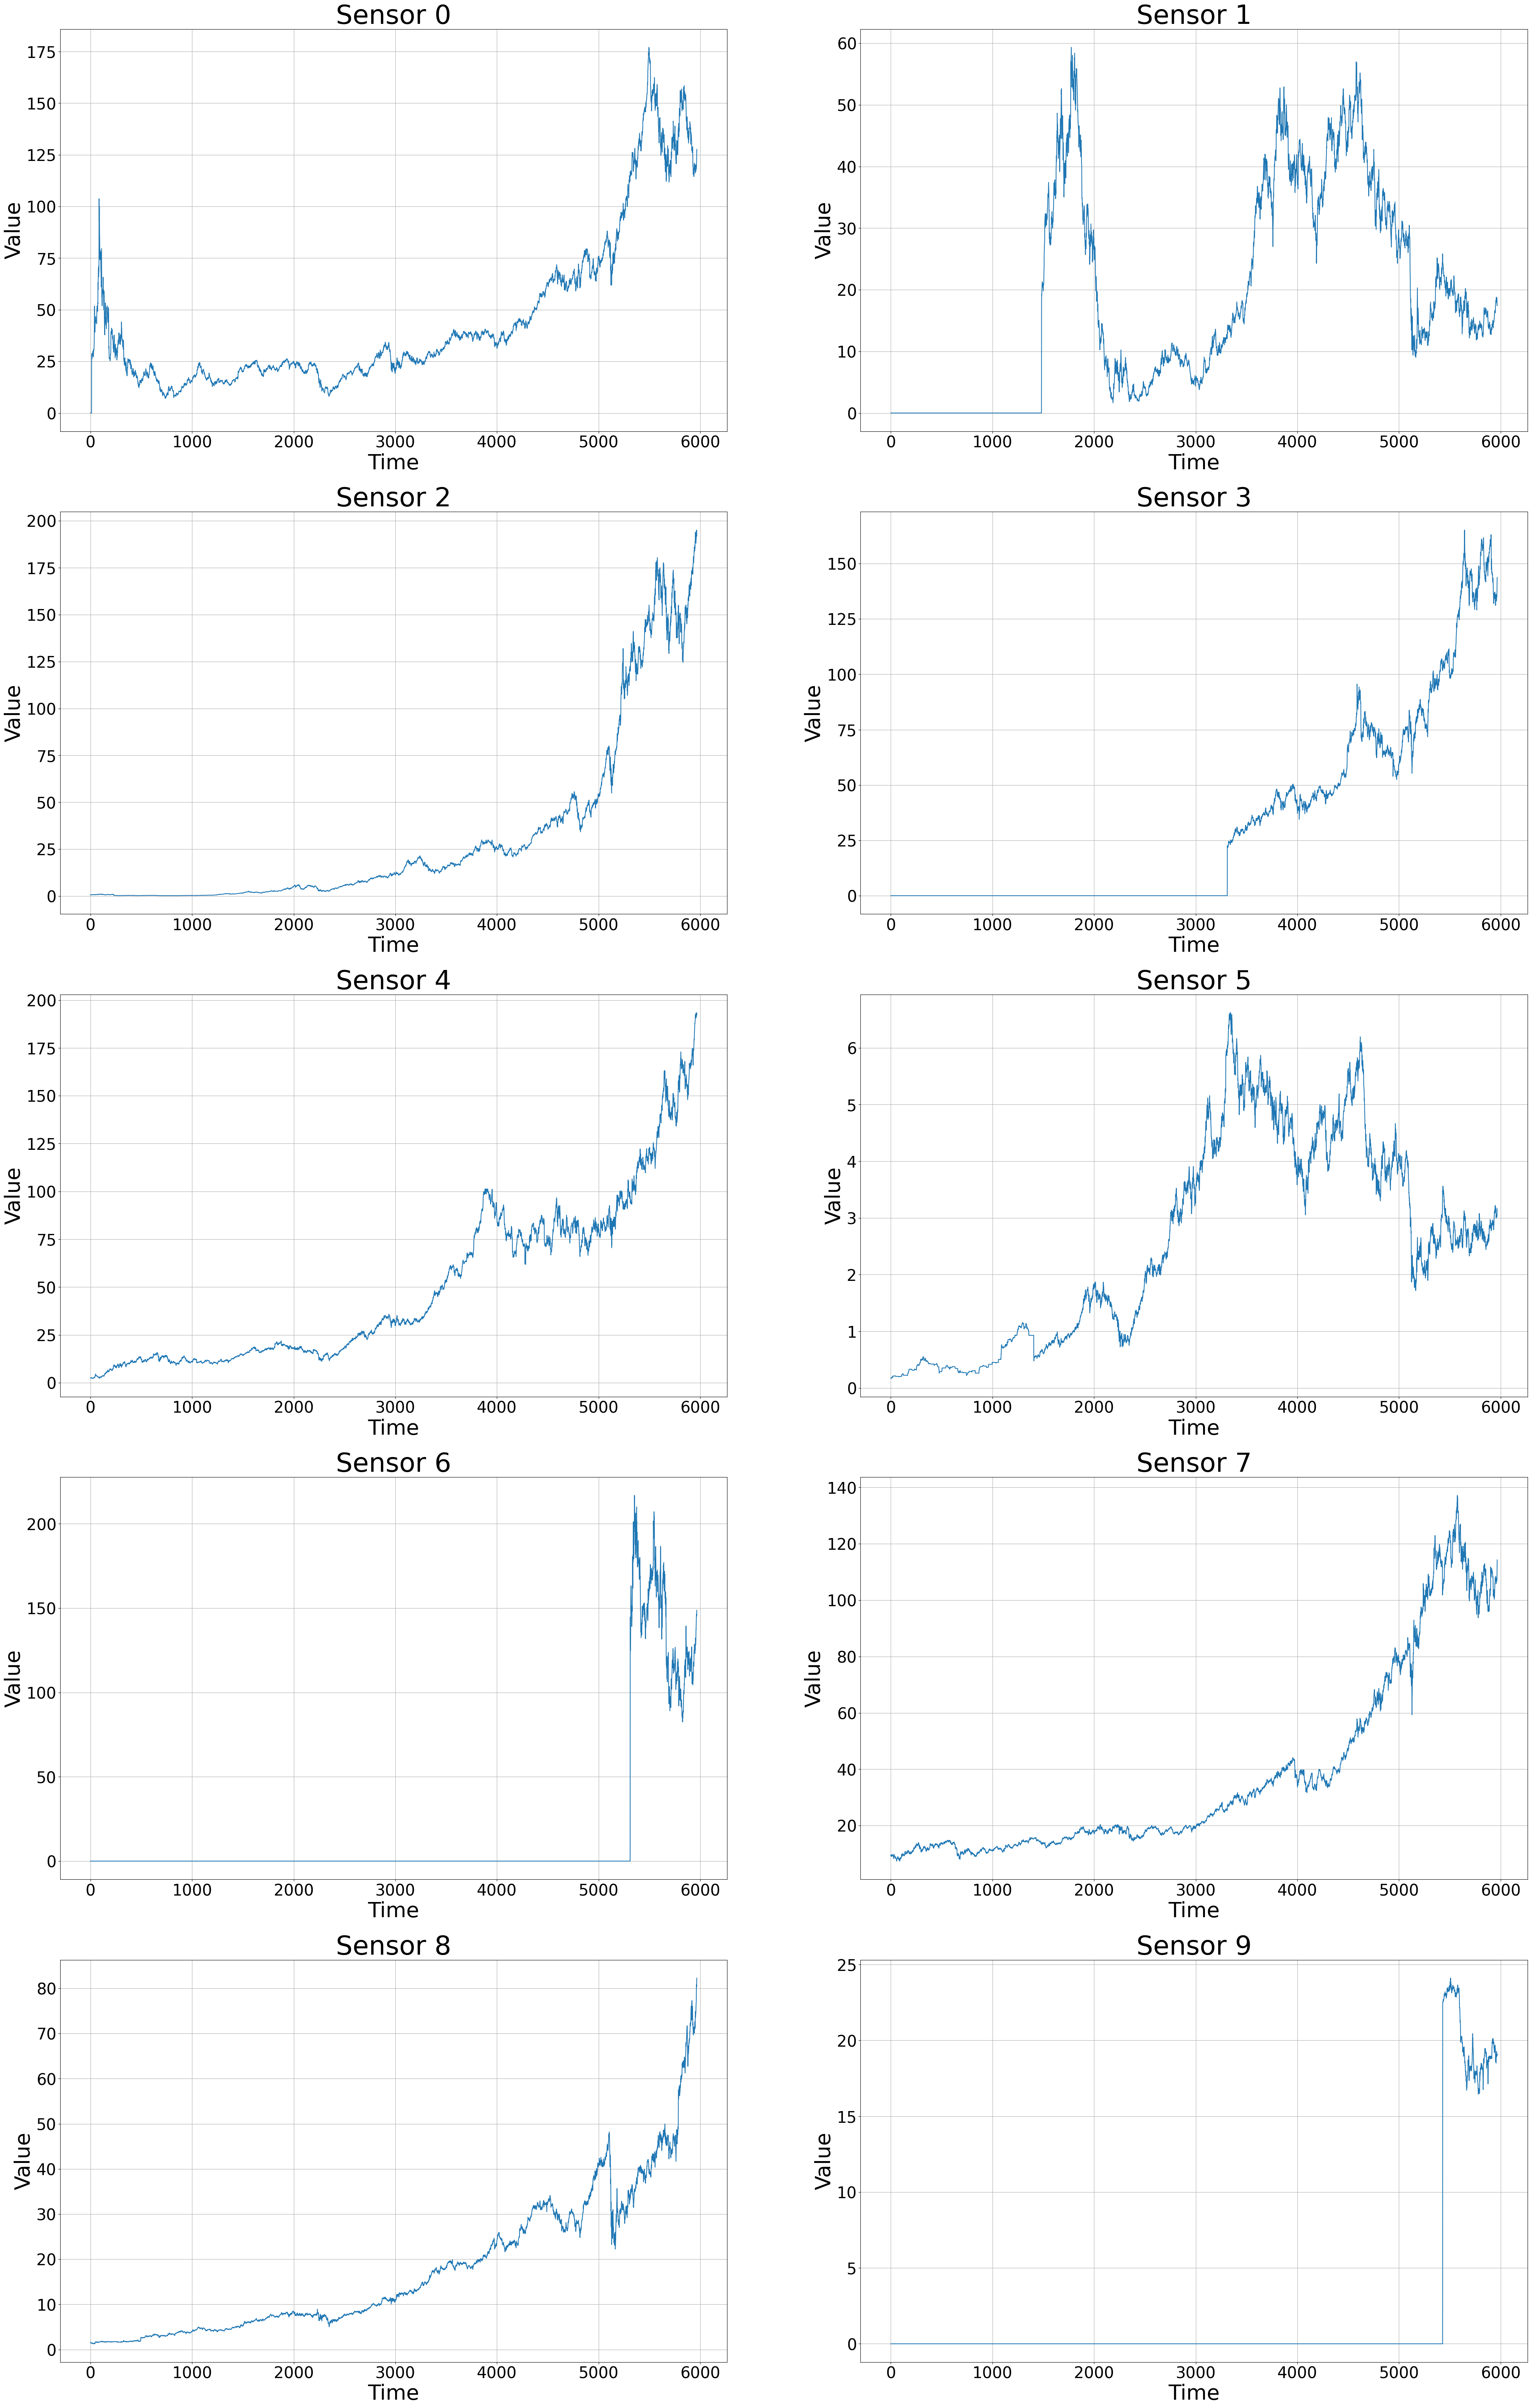

In [14]:
def plot_sensors_data(data):

  # Setting the paramters of the plots
  plt.rcParams.update({'xtick.labelsize': 30, 'ytick.labelsize' : 30, 'axes.labelsize' : 40, 'axes.titlesize': 50})

  # the number of the sensors
  sensors_num = len(data['SensorID'].unique())

  # the sensords id
  sensors_ids = list(data['SensorID'].unique())

  print(f"Number of sensors: {sensors_num}")
  print("Sensor IDs:", sensors_ids)

  # Define dimensions for plot
  f, axs = plt.subplots(ceil(sensors_num/2), 2,figsize=(50,80))
  axs = axs.flatten()

  # Loop through sensors ids
  for index, sensor_id in enumerate(sensors_ids):

    # filter the specific sensor`s data
    sensor_df = data[data['SensorID'] == sensor_id]

    axs[index].plot(sensor_df['#Time'], sensor_df['Value'])
    axs[index].set_title(f'Sensor {sensor_id}')
    axs[index].set_xlabel('Time')
    axs[index].set_ylabel('Value')
    axs[index].grid(True)


  plt.show()

# Call the plotting function to plot the data
plot_sensors_data(data)

In [15]:
def project_and_compute_residuals(data, mean, principal_subspace):
    centered_data = data - mean
    projection = centered_data @ principal_subspace @ principal_subspace.T
    residuals = centered_data - projection
    return residuals / np.linalg.norm(residuals)

def split_and_compute_pca(X, test_size=0.5, random_state=42, variance_retained=0.95):

    S1, S2 = train_test_split(X, test_size=test_size, random_state=random_state)

    mean = np.mean(S1, axis=0)

    covariance_matrix = np.cov(S1, rowvar=False)

    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    total_variance = np.sum(eigenvalues)
    variance_covered = 0
    r = 0
    while variance_covered / total_variance < variance_retained:
        variance_covered += eigenvalues[r]
        r += 1

    principal_subspace = eigenvectors[:, :r]

    return mean, principal_subspace, S2

def compute_p_t(residuals, nominal_residuals):
    p_t = np.sum(nominal_residuals > residuals) / len(nominal_residuals)
    return p_t

def compute_s_t(p_t, alpha):
    s_t = np.log(alpha / p_t)
    return s_t

In [20]:

def detect_anomalies(data):
    # Setting the parameters of the plots
    plt.rcParams.update({'xtick.labelsize': 30, 'ytick.labelsize': 30, 'axes.labelsize': 30, 'axes.titlesize': 30})

    # the number of the sensors
    sensors_num = len(data['SensorID'].unique())

    # the sensors id
    sensors_ids = list(data['SensorID'].unique())

    # Define dimensions for plot
    f, axs = plt.subplots(sensors_num, 1, figsize=(50, 200))
    axs = axs.flatten()

    # Create directories to store anomaly files and plots
    os.makedirs('anomaly_results_PCA', exist_ok=True)
    os.makedirs('anomaly_plots_PCA', exist_ok=True)

    # Loop through sensors ids
    for index, sensor_id in enumerate(sensors_ids):
        # filter the specific sensor's data
        sensor_df = data[data['SensorID'] == sensor_id]

        g_t = 0.0
        h = 0.1
        W = 100
        t = W
        alpha = 275

        anomalies = []
        p = []
        s = []
        g = []

        sensor_values = data.pivot(index='#Time', columns='SensorID', values='Value').fillna(0)

        
        while t < len(sensor_values):
            x_t = sensor_values.iloc[t].values

            window_data = sensor_values.iloc[t-W:t].values

            mean, principal_subspace, S2 = split_and_compute_pca(window_data, test_size=0.5, random_state=42, variance_retained=0.95)

            residuals = project_and_compute_residuals(np.array([x_t]), mean, principal_subspace)

            nominal_residuals = project_and_compute_residuals(S2, mean, principal_subspace)

            p_t = compute_p_t(residuals, nominal_residuals)
            p.append(p_t)

            if len(p) > 100:
                alpha = (sum(p[-100:]) / 100) * (92/100)

            s_t = compute_s_t(p_t, alpha)
            s.append(s_t)

            g_t = max(0, g_t + s_t)
            g.append(g_t)

            if g_t >= h:
                anomalies.append(sensor_values.index[t])
                g_t = 0

            t = t + 1

        # Plot the results
        axs[index].plot(sensor_df['#Time'], sensor_df['Value'], color='blue', alpha=0.5, linewidth=2)

        if anomalies:
            axs[index].scatter(anomalies, sensor_df.loc[sensor_df['#Time'].isin(anomalies), 'Value'].values, color='red', label='Anomalies', s=20)

        axs[index].set_title(f'Anomalies for sensor {sensor_id}')
        axs[index].set_xlabel('Time')
        axs[index].set_ylabel('Value')
        
        # Adjust grid settings
        axs[index].grid(True, which='major', linestyle='-', linewidth='0.5', color='gray')
        axs[index].grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
        axs[index].minorticks_on()
        
        # Adjust axis limits if needed
        # axs[index].set_xlim(min_time, max_time)
        # axs[index].set_ylim(min_value, max_value)

        # Save the individual plot as PNG with adjusted grid
        plt.figure(figsize=(50, 20))
        plt.plot(sensor_df['#Time'], sensor_df['Value'], color='blue', alpha=0.5, linewidth=2)
        if anomalies:
            plt.scatter(anomalies, sensor_df.loc[sensor_df['#Time'].isin(anomalies), 'Value'].values, color='red', label='Anomalies', s=20)
        plt.title(f'Anomalies for sensor {sensor_id}')
        plt.xlabel('Time')
        plt.ylabel('Value')
        
        # Adjust grid settings for individual plot
        plt.grid(True, which='major', linestyle='-', linewidth='0.5', color='gray')
        plt.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
        plt.minorticks_on()
        
        # Adjust axis limits if needed
        # plt.xlim(min_time, max_time)
        # plt.ylim(min_value, max_value)
        
        plot_file = os.path.join('anomaly_plots_PCA', f'sensor_{sensor_id}_plot.png')
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        plt.close()

        # Save anomalies to a text file
        anomaly_file = os.path.join('anomaly_results_PCA', f'sensor_{sensor_id}_anomalies.txt')
        with open(anomaly_file, 'w') as f:
            f.write(f"Anomalies for Sensor {sensor_id}:\n")
            for anomaly_time in anomalies:
                anomaly_value = sensor_df.loc[sensor_df['#Time'] == anomaly_time, 'Value'].values[0]
                f.write(f"Time: {anomaly_time}, Value: {anomaly_value}\n")

    # Show all plots in the script environment
    plt.show()

    print("Anomaly detection completed. Results saved in 'anomaly_results' and 'anomaly_plots' directories.")

# Call the function
detect_anomalies(data)





C:\Users\Mojta\AppData\Local\Temp\ipykernel_2996\1478332690.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  s_t = np.log(alpha / p_t)


Anomaly detection completed. Results saved in 'anomaly_results' and 'anomaly_plots' directories.
